# Chương 3: Tăng Trưởng Có Bền Vững Không?

1. **Tỷ trọng doanh thu**: Phân tích tỷ lệ New vs Returning customer theo thời gian.
2. **RFM Segmentation**: Phân khúc khách hàng theo Recency, Frequency, Monetary; gán tên kinh doanh.
3. **Cohort Retention**: Theo dõi tỷ lệ quay lại theo tháng acquisition.
4. **EDA Churn**: So sánh đặc trưng nhóm churn vs non-churn để đặt giả thuyết.
5. **Churn Prediction**: Baseline (Logistic Regression) → mô hình mạnh (XGBoost) với time split.
6. **Action List**: Danh sách VIP có churn risk cao kèm lý do và đề xuất.
7. **Lưu kết quả**: Ghi ngược vào PostgreSQL DWH.

**Câu hỏi kinh doanh:**
- Tỷ trọng doanh thu từ khách mới và khách quay lại thay đổi ra sao?
- Phân khúc nào đang tạo phần lớn doanh thu / lợi nhuận?
- Khách VIP nào giảm tần suất hoặc giá trị mua?
- Nhóm VIP nào có xác suất churn cao và cần giữ chân trước?


### 1. Cấu hình & Kết nối Database

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
from xgboost import XGBClassifier

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.database import get_dwh_engine

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_palette('Set2')

engine = get_dwh_engine()
print('Kết nối database DWH thành công!')


Kết nối database DWH thành công!


### 2. Tải Dữ Liệu Phân Tích Từ DWH

In [2]:
# ── Chốt định nghĩa target/horizon/VIP/churn (Pipeline Bước 1 - Chương 3) ──
OBS_MONTHS = 12       # Observation window: dùng 12 tháng lịch sử để tính RFM/feature tại mỗi snapshot
HORIZON    = 6        # Horizon dự báo: nhãn churn dựa trên 6 tháng SAU snapshot (không mua = churn)
VIP_PCTILE = 80        # VIP = top 20% khách hàng theo Monetary trong observation window (percentile >= 80)
CHURN_HIGH_RISK_THRESHOLD = 0.6   # Ngưỡng churn_prob để đưa vào action list "High Risk"

print('Tài liệu định nghĩa target — Chương 3:')
print(f'  • Observation window : {OBS_MONTHS} tháng lịch sử trước mỗi snapshot')
print(f'  • Horizon dự báo     : {HORIZON} tháng sau snapshot (không phát sinh đơn hàng → churn = 1)')
print(f'  • VIP threshold      : Top {100 - VIP_PCTILE}% khách hàng theo Monetary (percentile >= {VIP_PCTILE})')
print(f'  • High-risk churn    : churn_prob >= {CHURN_HIGH_RISK_THRESHOLD:.0%}')



Tài liệu định nghĩa target — Chương 3:
  • Observation window : 12 tháng lịch sử trước mỗi snapshot
  • Horizon dự báo     : 6 tháng sau snapshot (không phát sinh đơn hàng → churn = 1)
  • VIP threshold      : Top 20% khách hàng theo Monetary (percentile >= 80)
  • High-risk churn    : churn_prob >= 60%


In [3]:
# ── Lấy toàn bộ giao dịch Internet Sales ─────────────────────────
query_txn = """
    SELECT
        f.customer_key,
        f.order_date::date              AS order_date,
        f.sales_order_id,
        f.line_total                    AS revenue,
        f.gross_profit,
        f.unit_price_discount,
        p.category_name
    FROM dwh.fact_internet_sales f
    JOIN dwh.dim_product p ON f.product_key = p.product_key
    ORDER BY f.customer_key, f.order_date
"""
df_txn = pd.read_sql_query(query_txn, engine, parse_dates=['order_date'])
print(f'Tổng giao dịch: {len(df_txn):,} | Khách hàng: {df_txn.customer_key.nunique():,}')
print(f'Khoảng thời gian: {df_txn.order_date.min().date()} → {df_txn.order_date.max().date()}')


Tổng giao dịch: 121,317 | Khách hàng: 19,119
Khoảng thời gian: 2022-05-30 → 2025-06-29


In [4]:
# ── Lấy RFM Snapshot CHÍNH THỨC từ DWH (dwh.fact_customer_rfm_snapshot) ──
query_rfm_snap = """
    SELECT
        r.customer_key,
        r.snapshot_date_key,
        r.recency_days    AS recency,
        r.frequency_count AS frequency,
        r.monetary_amount AS monetary
    FROM dwh.fact_customer_rfm_snapshot r
    ORDER BY r.snapshot_date_key, r.customer_key
"""
df_rfm_dwh = pd.read_sql_query(query_rfm_snap, engine)

def parse_snapshot_date(key):
    s = str(key)
    if s.isdigit() and len(s) == 8:
        return pd.to_datetime(s, format='%Y%m%d')
    return pd.to_datetime(key)

df_rfm_dwh['snapshot_date'] = df_rfm_dwh['snapshot_date_key'].apply(parse_snapshot_date)
df_rfm_dwh = df_rfm_dwh.drop(columns=['snapshot_date_key'])

print(f'dwh.fact_customer_rfm_snapshot: {len(df_rfm_dwh):,} dòng | '
      f'{df_rfm_dwh.customer_key.nunique():,} khách hàng | '
      f'{df_rfm_dwh.snapshot_date.nunique()} kỳ snapshot '
      f'({df_rfm_dwh.snapshot_date.min().date()} → {df_rfm_dwh.snapshot_date.max().date()})')
df_rfm_dwh.head()


dwh.fact_customer_rfm_snapshot: 218,093 dòng | 18,613 khách hàng | 37 kỳ snapshot (2022-06-01 → 2025-06-01)


,customer_key,recency,frequency,monetary,snapshot_date
0,6,2,1,11397.4992,2022-06-01
1,8,2,1,20541.4072,2022-06-01
2,14,2,1,42813.4333,2022-06-01
3,50,2,1,1297.5901,2022-06-01
4,66,2,1,20645.6340,2022-06-01


In [5]:
# ── Xác định các kỳ snapshot hợp lệ ──────────────────────────────────
# Dùng ĐÚNG các kỳ snapshot đã tồn tại trong dwh.fact_customer_rfm_snapshot
# (không tự sinh danh sách tháng), chỉ giữ lại kỳ còn đủ HORIZON tháng dữ liệu
# giao dịch trong tương lai để gán nhãn churn một cách hợp lệ.
from dateutil.relativedelta import relativedelta

max_txn_date = df_txn['order_date'].max()
label_cutoff = max_txn_date - relativedelta(months=HORIZON)

snapshots = sorted(
    pd.Timestamp(d) for d in df_rfm_dwh['snapshot_date'].unique()
    if pd.Timestamp(d) <= label_cutoff
)

print(f'Số kỳ snapshot có trong DWH: {df_rfm_dwh["snapshot_date"].nunique()}')
print(f'Số kỳ snapshot hợp lệ (còn đủ {HORIZON} tháng horizon): {len(snapshots)}')
if snapshots:
    print(f'Từ {snapshots[0].date()} đến {snapshots[-1].date()}')


Số kỳ snapshot có trong DWH: 37
Số kỳ snapshot hợp lệ (còn đủ 6 tháng horizon): 31
Từ 2022-06-01 đến 2024-12-01


In [6]:
# ── Bổ sung feature + gán nhãn churn cho mỗi snapshot ────────────────
# Recency/Frequency/Monetary: lấy nguyên từ dwh.fact_customer_rfm_snapshot.
# Feature bổ sung (AOV, category diversity, promo rate, tenure, profit) và
# nhãn churn (dựa trên HORIZON tháng sau snapshot) được tính từ giao dịch.
records = []
df_txn['order_month'] = df_txn['order_date'].dt.to_period('M')

for snap_date in snapshots:
    obs_start_s = snap_date - relativedelta(months=OBS_MONTHS)
    horizon_end = snap_date + relativedelta(months=HORIZON)

    # Khách hàng + R/F/M chính thức tại snapshot này (theo DWH)
    df_rfm_s = df_rfm_dwh.loc[
        df_rfm_dwh['snapshot_date'] == snap_date,
        ['customer_key', 'recency', 'frequency', 'monetary']
    ].copy()
    if df_rfm_s.empty:
        continue

    # Giao dịch trong observation window — chỉ để tính feature bổ sung
    mask_obs = (df_txn['order_date'] > obs_start_s) & (df_txn['order_date'] <= snap_date)
    df_obs = df_txn[mask_obs].copy()

    # Giao dịch trong horizon — dùng làm nhãn churn
    mask_hor = (df_txn['order_date'] > snap_date) & (df_txn['order_date'] <= horizon_end)
    active_in_horizon = set(df_txn.loc[mask_hor, 'customer_key'].unique())

    extra = df_obs.groupby('customer_key').agg(
        aov                = ('revenue', lambda x: x.sum() / x.nunique()),
        profit_sum         = ('gross_profit', 'sum'),
        category_diversity = ('category_name', 'nunique'),
        promo_count        = ('unit_price_discount', lambda x: (x > 0).sum()),
        order_count_obs     = ('sales_order_id', 'nunique'),
    ).reset_index()
    # Dùng order_count_obs (tính trong cùng observation window) làm mẫu số cho
    # promo_rate — KHÔNG dùng 'frequency' của DWH vì có thể khác định nghĩa/khác window.
    extra['promo_rate'] = extra['promo_count'] / extra['order_count_obs']

    first_purchase = df_obs.groupby('customer_key')['order_date'].min().reset_index()
    first_purchase.columns = ['customer_key', 'first_purchase_date']
    extra = extra.merge(first_purchase, on='customer_key', how='left')
    extra['tenure_days'] = (snap_date - extra['first_purchase_date']).dt.days

    # Giữ toàn bộ khách hàng theo RFM DWH (grain chính thức); feature bổ sung
    # merge dạng left — khách không có giao dịch Internet Sales trong observation
    # window (ví dụ chỉ mua qua Reseller) sẽ có NaN ở các feature bổ sung.
    agg = df_rfm_s.merge(
        extra[['customer_key', 'aov', 'profit_sum', 'category_diversity',
               'promo_rate', 'tenure_days']],
        on='customer_key', how='left'
    )

    agg['snapshot_date'] = snap_date
    agg['churn'] = agg['customer_key'].apply(lambda c: 0 if c in active_in_horizon else 1)

    records.append(agg)

df_snap = pd.concat(records, ignore_index=True)

n_missing_extra = df_snap[['aov', 'category_diversity', 'promo_rate', 'tenure_days']].isna().any(axis=1).sum()
print(f'Customer-snapshot records: {len(df_snap):,}')
print(f'Churn rate tổng thể: {df_snap.churn.mean():.1%}')
print(f'Khách thiếu feature bổ sung (không có giao dịch Internet Sales trong observation window): {n_missing_extra:,}')
df_snap.head()


Customer-snapshot records: 123,059
Churn rate tổng thể: 70.7%
Khách thiếu feature bổ sung (không có giao dịch Internet Sales trong observation window): 27,572


,customer_key,recency,frequency,monetary,aov,profit_sum,category_diversity,promo_rate,tenure_days,snapshot_date,churn
0,6,2,1,11397.4992,876.730708,-652.9440,4.0,0.0,2.0,2022-06-01,0
1,8,2,1,20541.4072,2934.486743,1287.9033,3.0,0.0,2.0,2022-06-01,0
2,14,2,1,42813.4333,3567.786108,2700.5638,3.0,0.0,2.0,2022-06-01,0
3,50,2,1,1297.5901,324.397525,-214.8666,2.0,0.0,2.0,2022-06-01,0
4,66,2,1,20645.6340,2293.959333,1275.2821,3.0,0.0,2.0,2022-06-01,0


### 3. Phân Tích Tỷ Trọng Doanh Thu: New vs Returning Customer

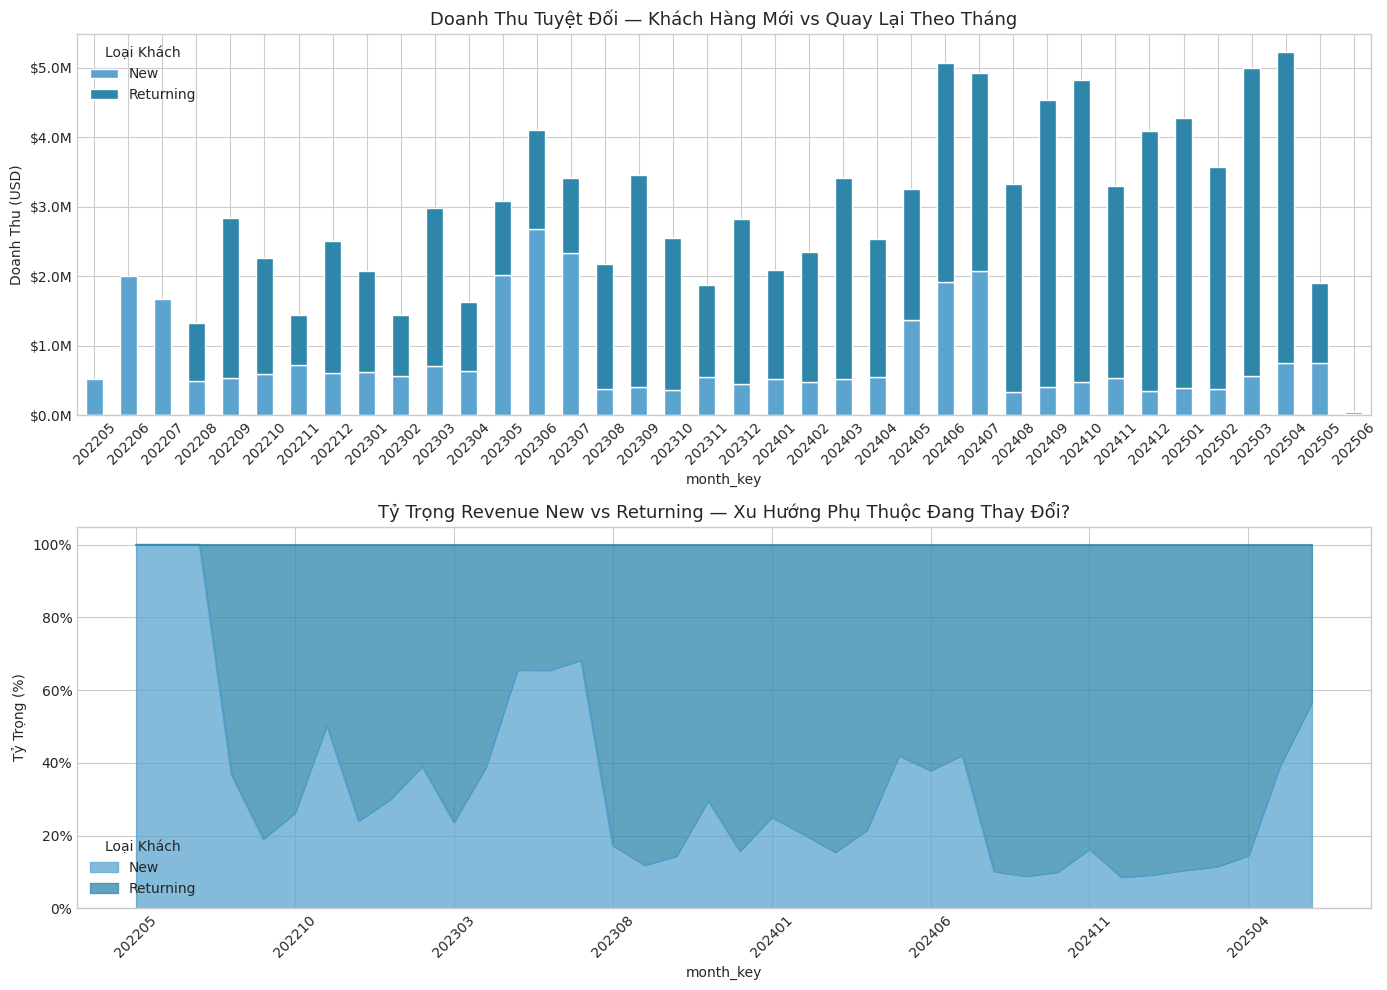

Tỷ trọng trung bình Khách Mới: 33.6%
Tỷ trọng trung bình Khách Quay Lại: 66.4%


In [7]:
# ── Dùng snapshot cuối cùng làm base ──────
query_nr = """
    WITH customer_first AS (
        SELECT customer_key, MIN(order_date) AS first_date
        FROM dwh.fact_internet_sales
        GROUP BY customer_key
    ),
    monthly AS (
        SELECT
            TO_CHAR(f.order_date, 'YYYYMM') AS month_key,
            CASE
                WHEN TO_CHAR(cf.first_date, 'YYYYMM') = TO_CHAR(f.order_date, 'YYYYMM')
                THEN 'New' ELSE 'Returning'
            END AS customer_type,
            SUM(f.line_total) AS revenue,
            COUNT(DISTINCT f.customer_key) AS customers
        FROM dwh.fact_internet_sales f
        JOIN customer_first cf ON f.customer_key = cf.customer_key
        GROUP BY 1, 2
    )
    SELECT * FROM monthly ORDER BY month_key, customer_type
"""
df_nr = pd.read_sql_query(query_nr, engine)
df_nr['month_key'] = df_nr['month_key'].astype(str)

# Pivot
pivot_rev = df_nr.pivot_table(index='month_key', columns='customer_type',
                               values='revenue', aggfunc='sum').fillna(0)
pivot_rev['total'] = pivot_rev.sum(axis=1)
for col in ['New', 'Returning']:
    if col in pivot_rev.columns:
        pivot_rev[col + '_share'] = pivot_rev[col] / pivot_rev['total']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue trị tuyệt đối
ax1 = axes[0]
pivot_rev[['New', 'Returning']].plot(kind='bar', stacked=True, ax=ax1,
                                      color=['#5BA4CF', '#2E86AB'], edgecolor='white')
ax1.set_title('Doanh Thu Tuyệt Đối — Khách Hàng Mới vs Quay Lại Theo Tháng', fontsize=13)
ax1.set_ylabel('Doanh Thu (USD)')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax1.legend(title='Loại Khách')

# Tỷ trọng %
ax2 = axes[1]
pivot_rev[['New_share', 'Returning_share']].rename(
    columns={'New_share': 'New', 'Returning_share': 'Returning'}
).plot(kind='area', stacked=True, ax=ax2, alpha=0.75,
       color=['#5BA4CF', '#2E86AB'])
ax2.set_title('Tỷ Trọng Revenue New vs Returning — Xu Hướng Phụ Thuộc Đang Thay Đổi?', fontsize=13)
ax2.set_ylabel('Tỷ Trọng (%)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Loại Khách')

plt.tight_layout()
plt.show()

# Insight nhanh
avg_new_share = pivot_rev['New_share'].mean()
print(f'Tỷ trọng trung bình Khách Mới: {avg_new_share:.1%}')
print(f'Tỷ trọng trung bình Khách Quay Lại: {1 - avg_new_share:.1%}')


### 4. RFM Segmentation

In [8]:
# ── Dùng snapshot gần nhất để phân khúc ──────────────────────────────────
latest_snap = df_snap['snapshot_date'].max()
df_rfm = df_snap[df_snap['snapshot_date'] == latest_snap].copy()

print(f'RFM tại snapshot: {latest_snap.date()} | {len(df_rfm):,} khách hàng')

# Tính điểm R/F/M (1-5, R cao = recency ngắn = tốt)
df_rfm['R_score'] = pd.qcut(df_rfm['recency'],    q=5, labels=[5, 4, 3, 2, 1]).astype(int)
df_rfm['F_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'].rank(method='first'),  q=5, labels=[1, 2, 3, 4, 5]).astype(int)
df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']

# Gán segment theo quy tắc kinh doanh
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP / Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

df_rfm['segment'] = df_rfm.apply(assign_segment, axis=1)

# VIP flag
vip_threshold = df_rfm['monetary'].quantile(VIP_PCTILE / 100)
df_rfm['is_vip'] = (df_rfm['monetary'] >= vip_threshold).astype(int)
print(f'VIP threshold (top {100 - VIP_PCTILE}%): monetary >= ${vip_threshold:,.0f}')
print(f'Số VIP: {df_rfm.is_vip.sum():,} ({df_rfm.is_vip.mean():.1%})')


RFM tại snapshot: 2024-12-01 | 12,106 khách hàng
VIP threshold (top 20%): monetary >= $3,578
Số VIP: 2,845 (23.5%)


           segment  customers  avg_recency  avg_frequency  avg_monetary  total_revenue  churn_rate  revenue_share
   VIP / Champions       1604    35.509352       2.971945  36570.731844   5.865945e+07    0.580424       0.683664
           At Risk       2453   362.368936       1.390950   7363.213483   1.806196e+07    0.443539       0.210509
             Loyal       3206    66.247973       1.480661   1185.863129   3.801877e+06    0.794448       0.044310
   Needs Attention       1692   333.573877       1.000000   1565.652072   2.649083e+06    0.419031       0.030875
              Lost        676   584.233728       1.000000   2351.339060   1.589505e+06    0.173077       0.018525
Potential Loyalist       2475    63.925657       1.000000    420.059107   1.039646e+06    0.850101       0.012117


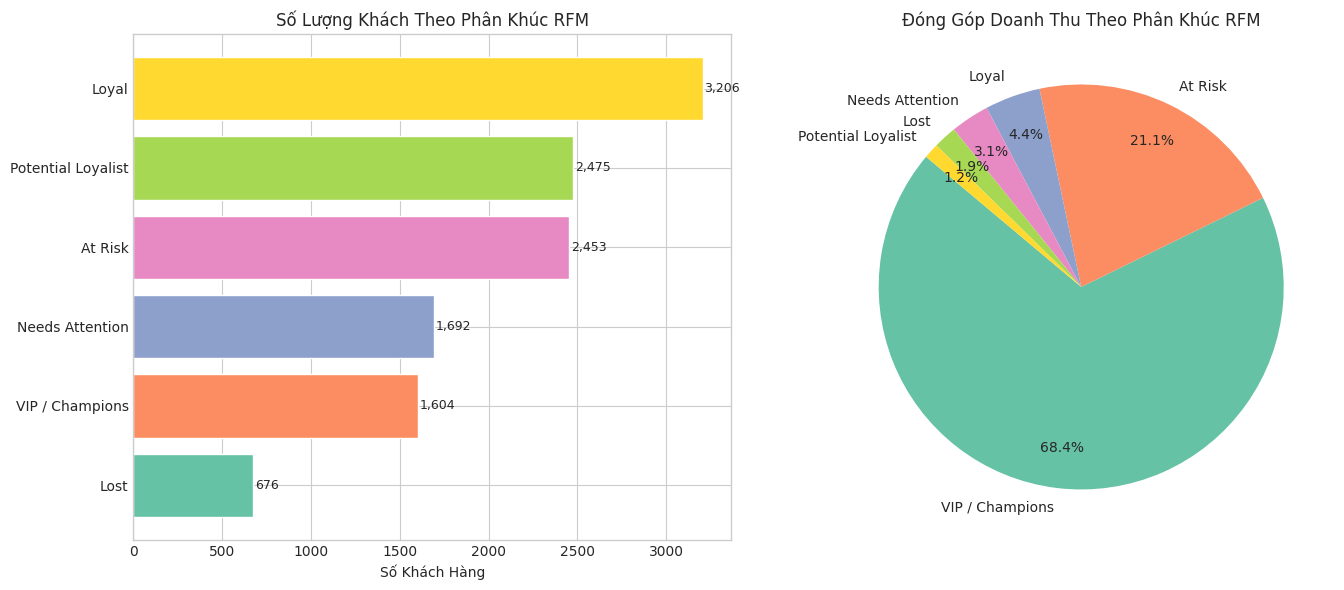

In [9]:
# ── Phân tích và trực quan hóa RFM ──────────────────────────────────────
seg_profile = df_rfm.groupby('segment').agg(
    customers      = ('customer_key', 'count'),
    avg_recency    = ('recency',   'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary',  'mean'),
    total_revenue  = ('monetary',  'sum'),
    churn_rate     = ('churn',     'mean'),
).reset_index()
seg_profile['revenue_share'] = seg_profile['total_revenue'] / seg_profile['total_revenue'].sum()
seg_profile = seg_profile.sort_values('total_revenue', ascending=False)

print(seg_profile.to_string(index=False))

# ── Dashboard: Segment Distribution + Revenue Share ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Treemap-style bar: số khách
seg_sorted = seg_profile.sort_values('customers', ascending=True)
ax1 = axes[0]
colors_seg = sns.color_palette('Set2', len(seg_sorted))
bars = ax1.barh(seg_sorted['segment'], seg_sorted['customers'], color=colors_seg, edgecolor='white')
ax1.set_title('Số Lượng Khách Theo Phân Khúc RFM', fontsize=12)
ax1.set_xlabel('Số Khách Hàng')
for bar, val in zip(bars, seg_sorted['customers']):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# Revenue contribution
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    seg_profile['total_revenue'],
    labels=seg_profile['segment'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(seg_profile)),
    startangle=140,
    pctdistance=0.8
)
ax2.set_title('Đóng Góp Doanh Thu Theo Phân Khúc RFM', fontsize=12)

plt.tight_layout()
plt.show()


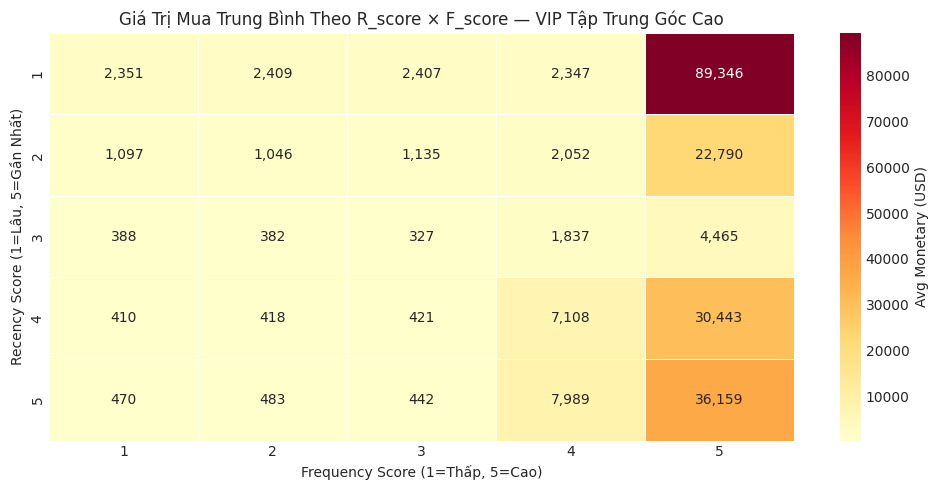

In [10]:
# ── Heatmap RFM score distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
rfm_heat = df_rfm.groupby(['R_score', 'F_score'])['monetary'].mean().reset_index()
rfm_pivot = rfm_heat.pivot(index='R_score', columns='F_score', values='monetary')
sns.heatmap(rfm_pivot, annot=True, fmt=',.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Avg Monetary (USD)'})
ax.set_title('Giá Trị Mua Trung Bình Theo R_score × F_score — VIP Tập Trung Góc Cao', fontsize=12)
ax.set_xlabel('Frequency Score (1=Thấp, 5=Cao)')
ax.set_ylabel('Recency Score (1=Lâu, 5=Gần Nhất)')
plt.tight_layout()
plt.show()


### 5. Cohort Retention Analysis

Cohorts: 38 tháng acquisition
Max period theo dõi: 36 tháng


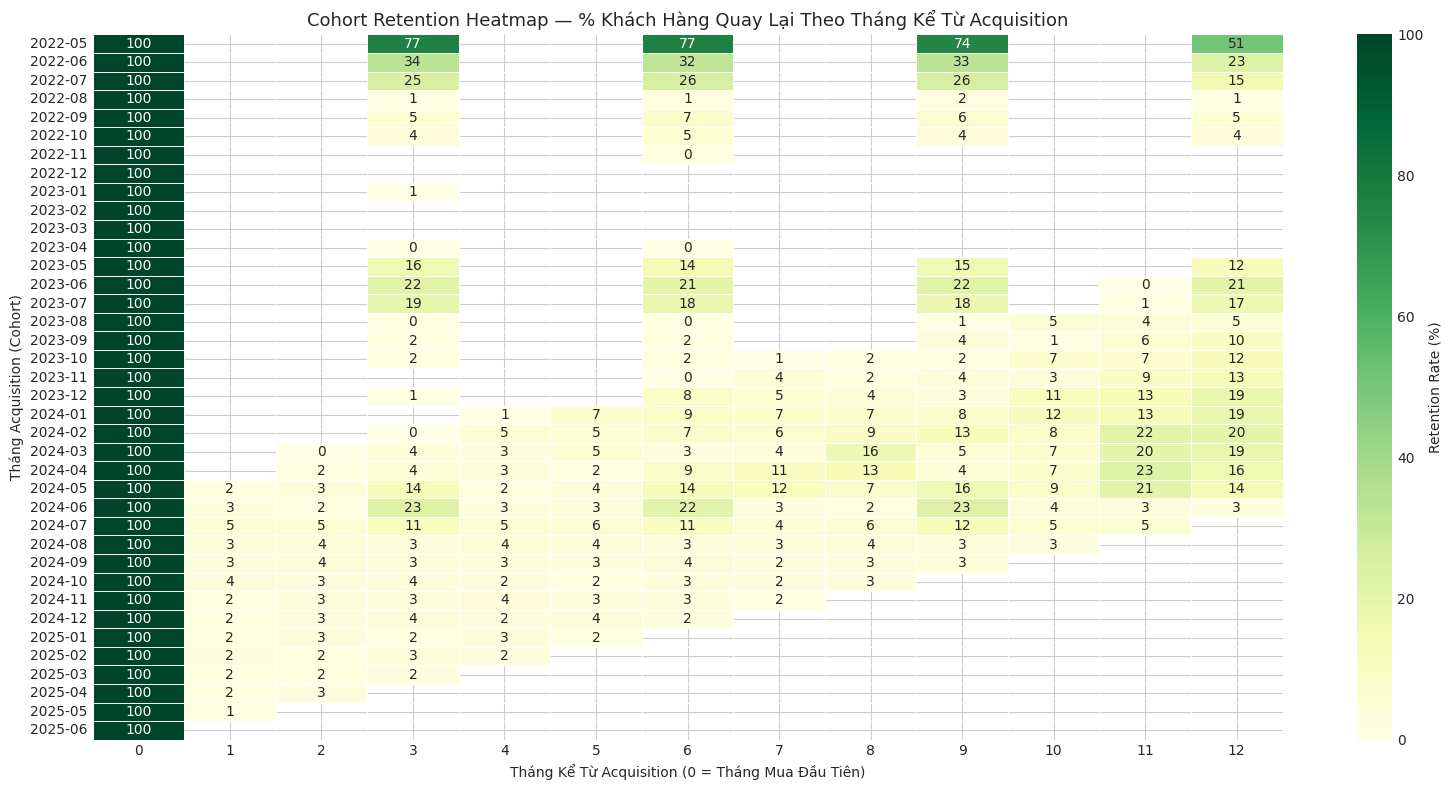

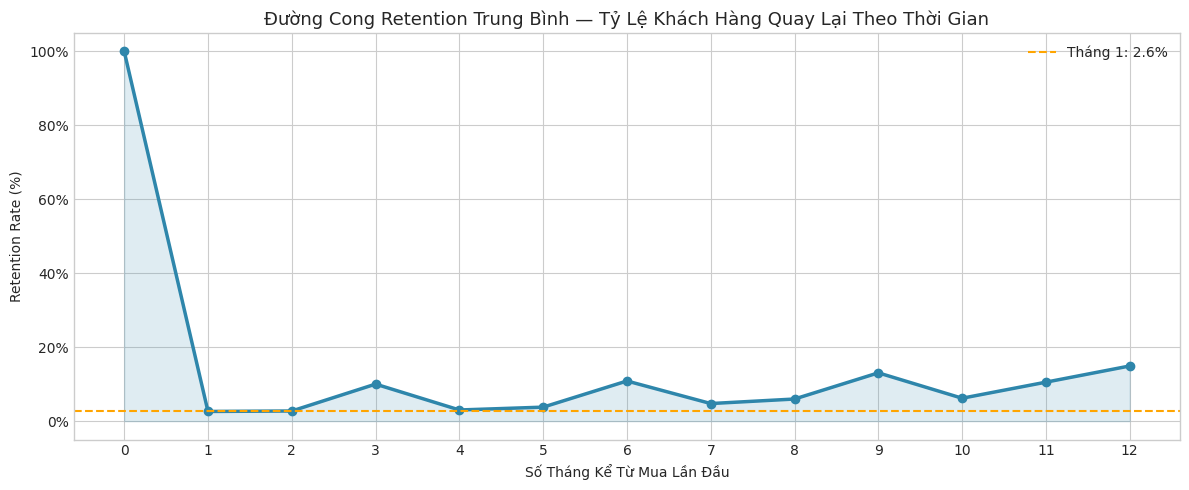

In [11]:
# ── Xây dựng cohort retention matrix ─────────────────────────────────────
query_cohort = """
    WITH first_purchase AS (
        SELECT customer_key,
               DATE_TRUNC('month', MIN(order_date)) AS cohort_month
        FROM dwh.fact_internet_sales
        GROUP BY customer_key
    ),
    monthly_activity AS (
        SELECT DISTINCT
            f.customer_key,
            DATE_TRUNC('month', f.order_date) AS activity_month
        FROM dwh.fact_internet_sales f
    )
    SELECT
        fp.cohort_month,
        EXTRACT(YEAR FROM AGE(ma.activity_month, fp.cohort_month)) * 12
            + EXTRACT(MONTH FROM AGE(ma.activity_month, fp.cohort_month)) AS period_number,
        COUNT(DISTINCT ma.customer_key) AS customers
    FROM first_purchase fp
    JOIN monthly_activity ma ON fp.customer_key = ma.customer_key
    WHERE ma.activity_month >= fp.cohort_month
    GROUP BY 1, 2
    ORDER BY 1, 2
"""
df_cohort = pd.read_sql_query(query_cohort, engine, parse_dates=['cohort_month'])
df_cohort['cohort_month'] = df_cohort['cohort_month'].dt.to_period('M').astype(str)
df_cohort['period_number'] = df_cohort['period_number'].astype(int)

# Pivot và tính retention %
cohort_pivot = df_cohort.pivot(index='cohort_month', columns='period_number', values='customers')
cohort_size  = cohort_pivot[0]
cohort_pct   = cohort_pivot.div(cohort_size, axis=0) * 100

print(f'Cohorts: {len(cohort_pct)} tháng acquisition')
print(f'Max period theo dõi: {cohort_pivot.columns.max()} tháng')

# ── Dashboard: Cohort Retention Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    cohort_pct.iloc[:, :13],   # 12 tháng đầu
    annot=True, fmt='.0f',
    cmap='YlGn', vmin=0, vmax=100,
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'}
)
ax.set_title('Cohort Retention Heatmap — % Khách Hàng Quay Lại Theo Tháng Kể Từ Acquisition', fontsize=13)
ax.set_xlabel('Tháng Kể Từ Acquisition (0 = Tháng Mua Đầu Tiên)')
ax.set_ylabel('Tháng Acquisition (Cohort)')
plt.tight_layout()
plt.show()

# Average retention curve
avg_retention = cohort_pct.mean(axis=0).iloc[:13]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_retention.index, avg_retention.values, marker='o', color='#2E86AB', lw=2.5)
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.15, color='#2E86AB')
ax.set_title('Đường Cong Retention Trung Bình — Tỷ Lệ Khách Hàng Quay Lại Theo Thời Gian', fontsize=13)
ax.set_xlabel('Số Tháng Kể Từ Mua Lần Đầu')
ax.set_ylabel('Retention Rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xticks(avg_retention.index)
ax.axhline(avg_retention.iloc[1], color='orange', ls='--', lw=1.5, label=f'Tháng 1: {avg_retention.iloc[1]:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()


### 6. EDA Churn — So Sánh Churn vs Non-Churn (Pipeline Bước 5)

Mục tiêu của bước này là tìm **giả thuyết driver churn** trước khi đưa vào mô hình, theo đúng yêu cầu pipeline (Bước 5 — EDA churn). Các phân tích thực hiện gồm:

1. **So sánh phân phối feature** (Recency, Frequency, Monetary, AOV, Category Diversity, Promotion Rate, Tenure) giữa nhóm Churn và Non-Churn bằng histogram + median.
2. **Bảng chênh lệch median (Diff %)** giữa hai nhóm để định lượng mức độ khác biệt của từng feature.
3. **Ma trận tương quan (correlation heatmap)** giữa các feature và churn label, giúp phát hiện feature có liên hệ tuyến tính mạnh/yếu với churn.
4. **Churn rate theo phân khúc RFM (segment)** — xác định segment nào có rủi ro churn cao nhất.
5. **Churn rate theo mức độ sử dụng khuyến mãi (promo usage)** — kiểm tra giả thuyết "khách hàng không dùng promotion có xu hướng rời bỏ cao hơn".

Kết quả các phân tích này được dùng làm **giả thuyết driver churn**, sẽ được đối chiếu lại với feature importance/SHAP ở Bước 7.

EDA dataset: 95,487 records | Churn rate: 74.3%


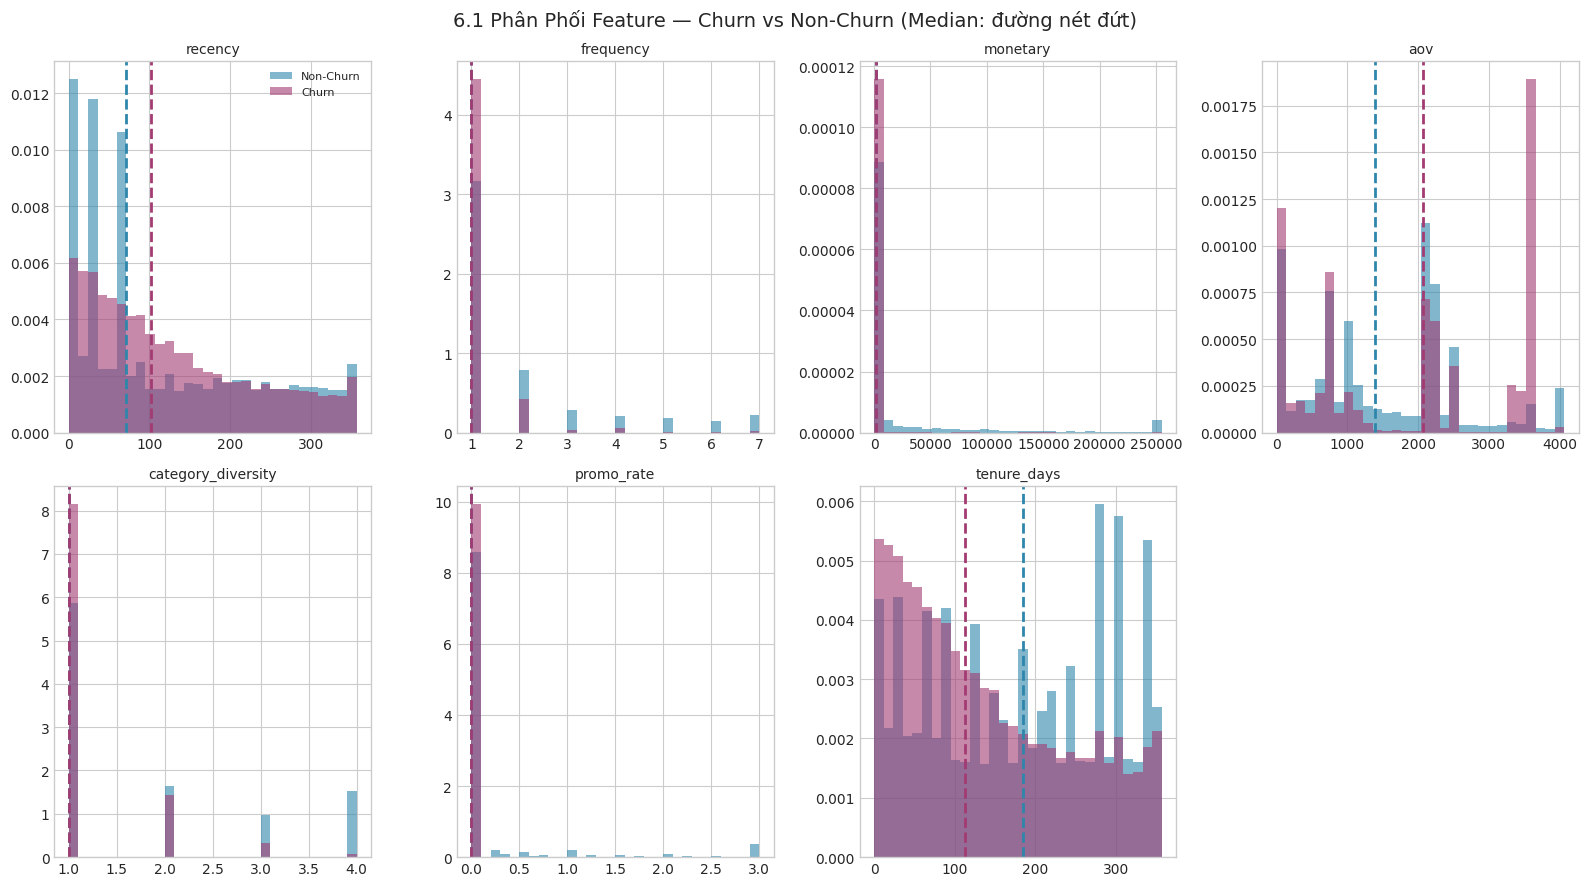


Khác biệt median giữa Churn vs Non-Churn:
                    Non-Churn (median)  Churn (median)  Diff %
recency                      71.000000        102.0000    43.7
frequency                     1.000000          1.0000     0.0
monetary                   2181.562500       2181.5625     0.0
aov                        1396.634275       2071.4196    48.3
category_diversity            1.000000          1.0000     0.0
promo_rate                    0.000000          0.0000     NaN
tenure_days                 185.000000        113.0000   -38.9


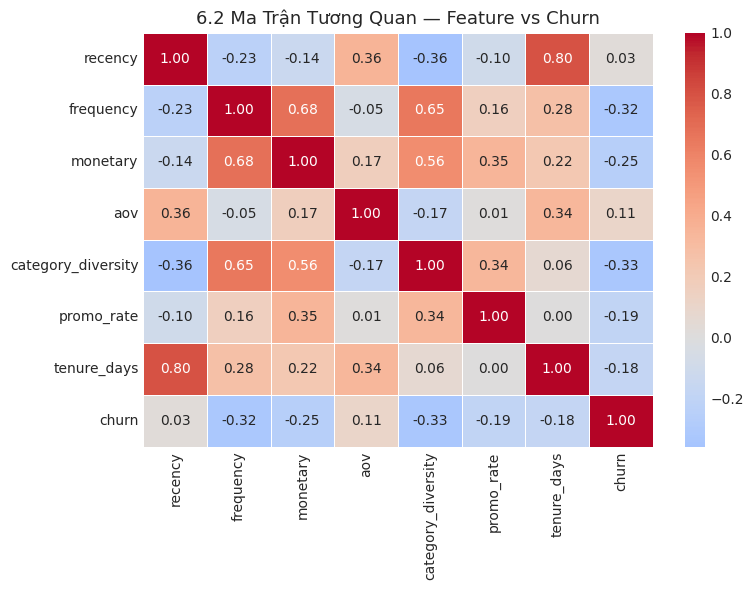


Tương quan từng feature với churn (sắp xếp theo |giá trị|):
category_diversity   -0.330414
frequency            -0.322493
monetary             -0.253215
promo_rate           -0.187088
tenure_days          -0.175257
aov                   0.107721
recency               0.027517

6.4 Churn rate theo mức độ sử dụng khuyến mãi:
                     churn_rate  n_records
promo_bucket                              
Không dùng (0%)        0.770297      91701
Thấp (0-25%)           0.076923        507
Trung bình (25-50%)    0.071082        619
Cao (>50%)             0.128991        783

>>> Giả thuyết driver churn rút ra từ EDA Bước 5: feature có |tương quan| lớn nhất với churn và segment/promo_bucket có churn rate cao nhất là các ứng viên driver chính, sẽ được đối chiếu lại với SHAP ở Bước 7.


In [12]:
# ── Dùng toàn bộ snapshot để EDA ─────────────────────────────────────────
feature_cols = ['recency', 'frequency', 'monetary', 'aov',
                'category_diversity', 'promo_rate', 'tenure_days']

df_eda = df_snap[feature_cols + ['churn', 'snapshot_date']].dropna()

print(f'EDA dataset: {len(df_eda):,} records | Churn rate: {df_eda.churn.mean():.1%}')

# ── 6.1 Phân phối feature: Churn vs Non-Churn ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    churn0 = df_eda.loc[df_eda['churn'] == 0, col].dropna()
    churn1 = df_eda.loc[df_eda['churn'] == 1, col].dropna()

    # Clip outlier cho dễ nhìn (99th pctile)
    cap = df_eda[col].quantile(0.99)
    churn0 = churn0.clip(upper=cap)
    churn1 = churn1.clip(upper=cap)

    ax.hist(churn0, bins=30, alpha=0.6, color='#2E86AB', label='Non-Churn', density=True)
    ax.hist(churn1, bins=30, alpha=0.6, color='#A23B72', label='Churn',     density=True)

    med0, med1 = churn0.median(), churn1.median()
    ax.axvline(med0, color='#2E86AB', lw=2, ls='--')
    ax.axvline(med1, color='#A23B72', lw=2, ls='--')

    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('6.1 Phân Phối Feature — Churn vs Non-Churn (Median: đường nét đứt)', fontsize=14)
plt.tight_layout()
plt.show()

# Bảng tóm tắt median + % chênh lệch
summary_eda = df_eda.groupby('churn')[feature_cols].median().T
summary_eda.columns = ['Non-Churn (median)', 'Churn (median)']
summary_eda['Diff %'] = ((summary_eda['Churn (median)'] - summary_eda['Non-Churn (median)'])
                          / summary_eda['Non-Churn (median)'].replace(0, np.nan) * 100).round(1)
print('\nKhác biệt median giữa Churn vs Non-Churn:')
print(summary_eda.to_string())

# ── 6.2 Ma trận tương quan giữa feature và churn ─────────────────────────
corr_matrix = df_eda[feature_cols + ['churn']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('6.2 Ma Trận Tương Quan — Feature vs Churn', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTương quan từng feature với churn (sắp xếp theo |giá trị|):')
print(corr_matrix['churn'].drop('churn').reindex(
    corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False).index
).to_string())

# ── 6.3 Churn rate theo phân khúc RFM ────────────────────────────────────
if 'segment' in df_snap.columns:
    churn_by_segment = (df_snap.dropna(subset=['churn', 'segment'])
                         .groupby('segment')['churn']
                         .agg(['mean', 'count'])
                         .rename(columns={'mean': 'churn_rate', 'count': 'n_records'})
                         .sort_values('churn_rate', ascending=False))
    print('\n6.3 Churn rate theo phân khúc RFM:')
    print(churn_by_segment.to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(churn_by_segment.index, churn_by_segment['churn_rate'],
           color='#A23B72', alpha=0.8, edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title('6.3 Churn Rate Theo Phân Khúc RFM', fontsize=13)
    ax.set_ylabel('Churn Rate')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# ── 6.4 Churn rate theo mức độ sử dụng khuyến mãi (promo_rate) ───────────
df_eda_promo = df_eda.copy()
df_eda_promo['promo_bucket'] = pd.cut(
    df_eda_promo['promo_rate'], bins=[-0.01, 0, 0.25, 0.5, 1.0],
    labels=['Không dùng (0%)', 'Thấp (0-25%)', 'Trung bình (25-50%)', 'Cao (>50%)']
)
churn_by_promo = df_eda_promo.groupby('promo_bucket', observed=True)['churn'].agg(['mean', 'count'])
print('\n6.4 Churn rate theo mức độ sử dụng khuyến mãi:')
print(churn_by_promo.rename(columns={'mean': 'churn_rate', 'count': 'n_records'}).to_string())

print('\n>>> Giả thuyết driver churn rút ra từ EDA Bước 5: feature có |tương quan| lớn nhất với '
      'churn và segment/promo_bucket có churn rate cao nhất là các ứng viên driver chính, '
      'sẽ được đối chiếu lại với SHAP ở Bước 7.')

### 7. Bước 6 — Huấn Luyện Baseline Model (Logistic Regression)

Theo pipeline, Bước 6 yêu cầu huấn luyện **baseline dễ giải thích** bằng Logistic Regression với **time split** (Train/Val/Test theo thời gian, không random split, để tránh leakage tương lai), đánh giá bằng PR-AUC, Recall@Top-K và Lift — thay vì chỉ dùng Accuracy.

In [13]:
# ── Time Split ───────────────────────────────────────────────────────────
snap_dates = sorted(df_snap['snapshot_date'].unique())
n = len(snap_dates)
train_end = snap_dates[int(n * 0.70)]
val_end   = snap_dates[int(n * 0.85)]

mask_train = df_snap['snapshot_date'] <= train_end
mask_val   = (df_snap['snapshot_date'] > train_end) & (df_snap['snapshot_date'] <= val_end)
mask_test  = df_snap['snapshot_date'] > val_end

df_train = df_snap[mask_train].dropna(subset=feature_cols + ['churn'])
df_val   = df_snap[mask_val].dropna(subset=feature_cols + ['churn'])
df_test  = df_snap[mask_test].dropna(subset=feature_cols + ['churn'])

X_train, y_train = df_train[feature_cols], df_train['churn']
X_val,   y_val   = df_val[feature_cols],   df_val['churn']
X_test,  y_test  = df_test[feature_cols],  df_test['churn']

print(f'Train  : {len(df_train):,} records ({train_end.date()}) | Churn: {y_train.mean():.1%}')
print(f'Val    : {len(df_val):,}  records ({val_end.date()}) | Churn: {y_val.mean():.1%}')
print(f'Test   : {len(df_test):,}  records                  | Churn: {y_test.mean():.1%}')


Train  : 43,229 records (2024-03-01) | Churn: 86.3%
Val    : 19,669  records (2024-08-01) | Churn: 61.5%
Test   : 32,589  records                  | Churn: 66.2%


In [14]:
# ──Baseline — Logistic Regression ───────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

y_val_prob_lr = lr.predict_proba(X_val_sc)[:, 1]
pr_auc_lr = average_precision_score(y_val, y_val_prob_lr)
roc_lr    = roc_auc_score(y_val, y_val_prob_lr)

print(f'[Logistic Regression] Val PR-AUC: {pr_auc_lr:.3f} | ROC-AUC: {roc_lr:.3f}')

# Recall@Top-K và Lift (K=10%)
k = max(1, int(len(y_val) * 0.10))
top_k_idx      = np.argsort(y_val_prob_lr)[::-1][:k]
lift_topk_lr   = y_val.iloc[top_k_idx].mean() / y_val.mean()
recall_topk_lr = y_val.iloc[top_k_idx].sum() / y_val.sum()
print(f'[Logistic Regression] Lift@Top10%: {lift_topk_lr:.2f}x | Recall@Top10%: {recall_topk_lr:.1%}')


[Logistic Regression] Val PR-AUC: 0.639 | ROC-AUC: 0.554
[Logistic Regression] Lift@Top10%: 1.00x | Recall@Top10%: 10.0%


### 8. Bước 7 — Huấn Luyện Mô Hình Mạnh & Chọn Mô Hình Tốt Nhất

Bước 7 huấn luyện **mô hình mạnh hơn (XGBoost)**, so sánh với baseline ở Bước 6 trên tập Validation (PR-AUC, ROC-AUC, Lift@Top10%, Recall@Top10%), sau đó **chọn ra 1 mô hình tốt nhất** (`best_model`) để dùng cho toàn bộ phần còn lại của pipeline (SHAP, VIP churn risk matrix, action list, ghi DWH). Tiêu chí chọn mô hình: **PR-AUC trên Validation** (phù hợp bài toán mất cân bằng lớp hơn ROC-AUC/Accuracy).

In [15]:
# ──XGBoost ──────────────────────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

y_val_prob_xgb = xgb.predict_proba(X_val)[:, 1]
pr_auc_xgb = average_precision_score(y_val, y_val_prob_xgb)
roc_xgb    = roc_auc_score(y_val, y_val_prob_xgb)

top_k_idx_xgb   = np.argsort(y_val_prob_xgb)[::-1][:k]
lift_topk_xgb   = y_val.iloc[top_k_idx_xgb].mean() / y_val.mean()
recall_topk_xgb = y_val.iloc[top_k_idx_xgb].sum() / y_val.sum()

print(f'[XGBoost]            Val PR-AUC: {pr_auc_xgb:.3f} | ROC-AUC: {roc_xgb:.3f}')
print(f'[XGBoost]            Lift@Top10%: {lift_topk_xgb:.2f}x | Recall@Top10%: {recall_topk_xgb:.1%}')


[XGBoost]            Val PR-AUC: 0.649 | ROC-AUC: 0.562
[XGBoost]            Lift@Top10%: 1.08x | Recall@Top10%: 10.8%


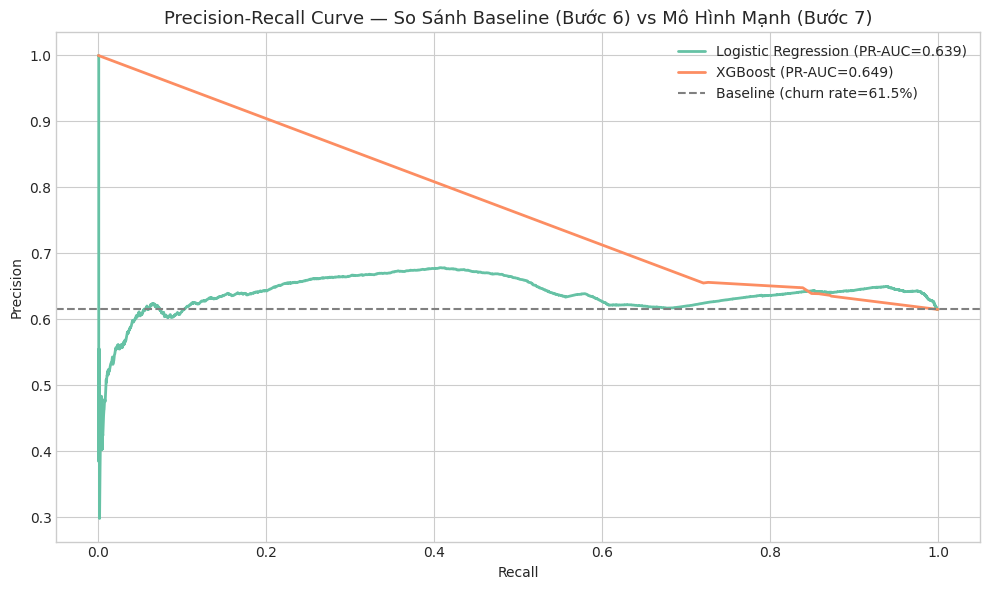

Bảng so sánh Baseline (Bước 6) vs Mô hình mạnh (Bước 7):
                     PR-AUC  ROC-AUC  Lift@Top10%  Recall@Top10%
Logistic Regression   0.639    0.554        0.996          0.100
XGBoost               0.649    0.562        1.083          0.108

>>> Mô hình tốt nhất được chọn (Bước 7): XGBoost (Val PR-AUC = 0.649)

[TEST SET — XGBoost] PR-AUC: 0.638 | ROC-AUC: 0.450 | Lift@Top10%: 0.94x | Recall@Top10%: 9.4%


In [16]:
# ── So sánh mô hình trên Validation & CHỌN MÔ HÌNH TỐT NHẤT ──────────────
fig, ax = plt.subplots(figsize=(10, 6))

model_results = {
    'Logistic Regression': {'probs': y_val_prob_lr,  'pr_auc': pr_auc_lr,  'roc_auc': roc_lr,
                             'lift': lift_topk_lr,  'recall': recall_topk_lr, 'model': lr,
                             'X_test': X_test_sc},
    'XGBoost':             {'probs': y_val_prob_xgb, 'pr_auc': pr_auc_xgb, 'roc_auc': roc_xgb,
                             'lift': lift_topk_xgb, 'recall': recall_topk_xgb, 'model': xgb,
                             'X_test': X_test},
}

for label, res in model_results.items():
    prec, rec, _ = precision_recall_curve(y_val, res['probs'])
    ax.plot(rec, prec, lw=2, label=f"{label} (PR-AUC={res['pr_auc']:.3f})")

baseline_rate = y_val.mean()
ax.axhline(baseline_rate, ls='--', color='grey', lw=1.5, label=f'Baseline (churn rate={baseline_rate:.1%})')
ax.set_title('Precision-Recall Curve — So Sánh Baseline (Bước 6) vs Mô Hình Mạnh (Bước 7)', fontsize=13)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
plt.tight_layout()
plt.show()

# ── Bảng so sánh tổng hợp (Bước 6 vs Bước 7) ─────────────────────────────
comparison_table = pd.DataFrame({
    label: {'PR-AUC': res['pr_auc'], 'ROC-AUC': res['roc_auc'],
            'Lift@Top10%': res['lift'], 'Recall@Top10%': res['recall']}
    for label, res in model_results.items()
}).T
print('Bảng so sánh Baseline (Bước 6) vs Mô hình mạnh (Bước 7):')
print(comparison_table.round(3).to_string())

# ── Chọn mô hình tốt nhất dựa trên PR-AUC trên Validation ────────────────
best_model_name = comparison_table['PR-AUC'].idxmax()
best_model       = model_results[best_model_name]['model']
best_X_test      = model_results[best_model_name]['X_test']

print(f"\n>>> Mô hình tốt nhất được chọn (Bước 7): {best_model_name} "
      f"(Val PR-AUC = {comparison_table.loc[best_model_name, 'PR-AUC']:.3f})")

# ── Đánh giá MÔ HÌNH TỐT NHẤT trên TEST SET (chỉ chạy sau khi đã chọn) ───
y_test_prob   = best_model.predict_proba(best_X_test)[:, 1]
pr_auc_test   = average_precision_score(y_test, y_test_prob)
roc_test      = roc_auc_score(y_test, y_test_prob)
k_test        = max(1, int(len(y_test) * 0.10))
top_k_test    = np.argsort(y_test_prob)[::-1][:k_test]
lift_test     = y_test.iloc[top_k_test].mean() / y_test.mean()
recall_test   = y_test.iloc[top_k_test].sum() / y_test.sum()
print(f'\n[TEST SET — {best_model_name}] PR-AUC: {pr_auc_test:.3f} | ROC-AUC: {roc_test:.3f} | '
      f'Lift@Top10%: {lift_test:.2f}x | Recall@Top10%: {recall_test:.1%}')

### 9. SHAP Feature Importance (Trên Mô Hình Tốt Nhất Đã Chọn)

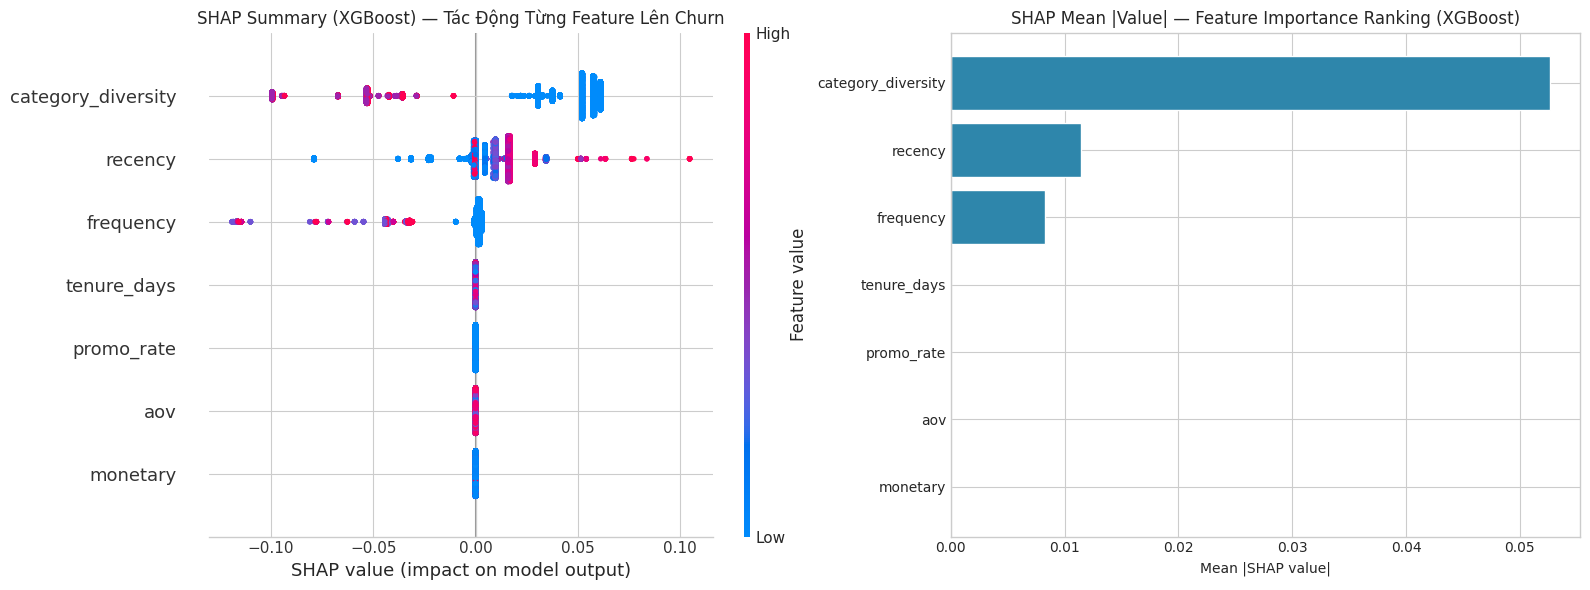


>>> Đối chiếu với giả thuyết driver churn từ EDA (Bước 5): feature có SHAP cao nhất nên trùng khớp (hoặc giải thích được) với feature có |tương quan| cao nhất ở Bước 5.


In [17]:
# ── SHAP trên tập validation, dùng MÔ HÌNH TỐT NHẤT (best_model) đã chọn ở Bước 7 ──
best_val_X = X_val if best_model_name == 'XGBoost' else X_val_sc

if best_model_name == 'XGBoost':
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(best_val_X)
else:
    explainer = shap.LinearExplainer(best_model, X_train_sc)
    shap_vals = explainer.shap_values(best_val_X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Summary beeswarm
plt.sca(axes[0])
shap.summary_plot(shap_vals, best_val_X, feature_names=feature_cols,
                  show=False, plot_size=None)
axes[0].set_title(f'SHAP Summary ({best_model_name}) — Tác Động Từng Feature Lên Churn', fontsize=12)

# Bar importance
shap_importance = pd.DataFrame({
    'feature':    feature_cols,
    'mean_shap':  np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_shap', ascending=True)

axes[1].barh(shap_importance['feature'], shap_importance['mean_shap'],
             color='#2E86AB', edgecolor='white')
axes[1].set_title(f'SHAP Mean |Value| — Feature Importance Ranking ({best_model_name})', fontsize=12)
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.show()

print('\n>>> Đối chiếu với giả thuyết driver churn từ EDA (Bước 5): feature có SHAP cao nhất '
      'nên trùng khớp (hoặc giải thích được) với feature có |tương quan| cao nhất ở Bước 5.')

### 10. VIP Churn Risk Matrix & Action List

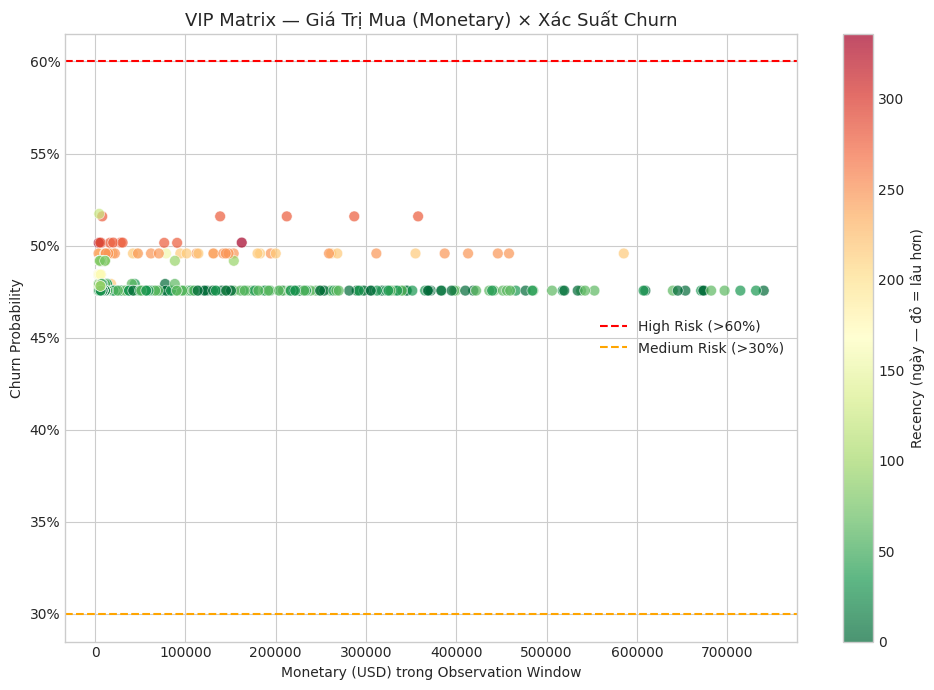

VIP tổng: 2,010
churn_risk_band
Medium (30–60%)    2010
Low (<30%)            0
High (>60%)           0


In [18]:
# ── Tính churn probability trên toàn bộ latest snapshot ─────────────────
df_latest = df_snap[df_snap['snapshot_date'] == latest_snap].copy()
df_latest = df_latest.dropna(subset=feature_cols)

df_latest_X = df_latest[feature_cols] if best_model_name == 'XGBoost' else scaler.transform(df_latest[feature_cols])
df_latest['churn_prob'] = best_model.predict_proba(df_latest_X)[:, 1]
df_latest['churn_risk_band'] = pd.cut(
    df_latest['churn_prob'],
    bins=[0, 0.3, 0.6, 1.01],
    labels=['Low (<30%)', 'Medium (30–60%)', 'High (>60%)']
)

# Gắn segment RFM
df_latest = df_latest.merge(df_rfm[['customer_key', 'segment', 'R_score',
                                     'F_score', 'M_score', 'is_vip']],
                             on='customer_key', how='left')

# ── Dashboard: VIP Matrix ────────────────────────────────────────────────
df_vip_plot = df_latest[df_latest['is_vip'] == 1].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_vip_plot['monetary'],
    df_vip_plot['churn_prob'],
    c=df_vip_plot['recency'],
    cmap='RdYlGn_r',
    s=60, alpha=0.7, edgecolors='white', linewidths=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Recency (ngày — đỏ = lâu hơn)')
ax.axhline(0.6, color='red',    ls='--', lw=1.5, label='High Risk (>60%)')
ax.axhline(0.3, color='orange', ls='--', lw=1.5, label='Medium Risk (>30%)')
ax.set_title('VIP Matrix — Giá Trị Mua (Monetary) × Xác Suất Churn', fontsize=13)
ax.set_xlabel('Monetary (USD) trong Observation Window')
ax.set_ylabel('Churn Probability')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend()
plt.tight_layout()
plt.show()

print(f'VIP tổng: {len(df_vip_plot):,}')
print(df_vip_plot['churn_risk_band'].value_counts().to_string())


In [19]:
# ── Action List: VIP + High Risk ─────────────────────────────────────────
df_action = df_latest[
    (df_latest['is_vip'] == 1) & (df_latest['churn_prob'] >= CHURN_HIGH_RISK_THRESHOLD)
].copy()

# Category mua gần nhất trước snapshot (yêu cầu tài liệu: lý do + segment + last category)
last_cat = (
    df_txn[df_txn['order_date'] <= latest_snap]
    .sort_values('order_date')
    .groupby('customer_key')['category_name']
    .last()
    .reset_index()
    .rename(columns={'category_name': 'last_category'})
)
df_action = df_action.merge(last_cat, on='customer_key', how='left')

# Lý do ngắn gọn dựa trên SHAP cá nhân (top 2 features)
def get_reason(row):
    row_df = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
    if best_model_name != 'XGBoost':
        row_df = pd.DataFrame(scaler.transform(row_df), columns=feature_cols)
    shap_row = explainer.shap_values(row_df)[0]
    top2 = pd.Series(shap_row, index=feature_cols).abs().nlargest(2).index.tolist()
    return ' | '.join(top2)

df_action['reason_code'] = df_action.apply(get_reason, axis=1)

# Đề xuất ưu đãi đơn giản
def recommend(row):
    if row['recency'] > 180:
        return 'Win-back campaign — ưu đãi cá nhân hoá'
    elif row['frequency'] <= 2:
        return 'Loyalty program — khuyến khích mua thêm'
    elif row['monetary'] > df_latest['monetary'].quantile(0.9):
        return 'VIP concierge — chăm sóc 1-1'
    else:
        return 'Retention email + discount nhỏ'

df_action['recommended_action'] = df_action.apply(recommend, axis=1)

action_cols = ['customer_key', 'segment', 'last_category', 'monetary', 'recency',
               'frequency', 'churn_prob', 'reason_code', 'recommended_action']
df_action_out = df_action[action_cols].sort_values('churn_prob', ascending=False)

print(f'Danh sách VIP High-Risk cần giữ chân: {len(df_action_out):,} khách hàng\n')
print(df_action_out.head(20).to_string(index=False))


Danh sách VIP High-Risk cần giữ chân: 0 khách hàng

Empty DataFrame
Columns: [customer_key, segment, last_category, monetary, recency, frequency, churn_prob, reason_code, recommended_action]
Index: []


### 11. Ghi Kết Quả Vào Database DWH

In [20]:
# ── 1. Customer RFM + Churn Probability (latest snapshot) ─────────────────
out_churn = df_latest[[
    'customer_key', 'snapshot_date',
    'recency', 'frequency', 'monetary', 'aov',
    'category_diversity', 'promo_rate', 'tenure_days',
    'churn', 'churn_prob', 'churn_risk_band',
    'segment', 'R_score', 'F_score', 'M_score', 'is_vip'
]].copy()
out_churn.columns = [c.lower() for c in out_churn.columns]
out_churn['churn_risk_band'] = out_churn['churn_risk_band'].astype(str)
out_churn.to_sql('customer_churn_predictions', engine, schema='ml',
                 if_exists='replace', index=False)
print(f'Lưu ml.customer_churn_predictions: {len(out_churn):,} rows')

# ── 2. Action List ─────────────────────────────────────────────────────────
df_action_out.columns = [c.lower() for c in df_action_out.columns]
df_action_out['churn_risk_band'] = 'High (>60%)'
df_action_out['snapshot_date'] = latest_snap
df_action_out.to_sql('customer_retention_actions', engine, schema='ml',
                     if_exists='replace', index=False)
print(f'Lưu ml.customer_retention_actions: {len(df_action_out):,} rows')

# ── 3. Cohort Retention ────────────────────────────────────────────────────
cohort_out = cohort_pct.reset_index().melt(
    id_vars='cohort_month', var_name='period_number', value_name='retention_pct')
cohort_out.to_sql('customer_cohort_retention', engine, schema='ml',
                  if_exists='replace', index=False)
print(f'Lưu ml.customer_cohort_retention: {len(cohort_out):,} rows')

# ── 4. New vs Returning Revenue ────────────────────────────────────────────
df_nr.to_sql('customer_new_vs_returning', engine, schema='ml',
             if_exists='replace', index=False)
print(f'Lưu ml.customer_new_vs_returning: {len(df_nr):,} rows')

print('\nHoàn tất — Chương 3 đã lưu đầy đủ vào DWH!')


Lưu ml.customer_churn_predictions: 9,957 rows
Lưu ml.customer_retention_actions: 0 rows
Lưu ml.customer_cohort_retention: 1,406 rows
Lưu ml.customer_new_vs_returning: 73 rows

Hoàn tất — Chương 3 đã lưu đầy đủ vào DWH!
